---
# 🏠 Домашнє завдання
---

**Тема:** Matplotlib + часові ряди

**Датасет:** Оберіть ОДИН з варіантів:
- Ціни іншої криптовалюти (ETH, SOL, DOGE) або акції (AAPL, TSLA, NVDA)
- Погодні дані вашого міста (temperature, precipitation)
- Будь-який часовий ряд, який вам цікавий (>365 днів)

**Завдання:**

1. Завантажити дані, зробити Date індексом, `info()` + `describe()`

2. Побудувати **базовий line chart** (OOP-стиль, заголовок, підписи осей, сітка)

3. Додати **rolling mean** (два різних вікна) + пояснити, як вікно впливає на результат

4. Побудувати **fill_between** (діапазон мін-макс або ±σ)

5. Порівняти **2 роки** на одному графіку (нормалізація!)

6. Зробити **1 графік з анотаціями** (мінімум 2 події + axvline або axvspan)

7. Створити **dashboard** (GridSpec або subplot_mosaic, мінімум 4 графіки, нерівна сітка)

8. Написати **5 висновків** про ваші дані у Markdown

📌 Кожен графік має бути в OOP-стилі, з `tight_layout`, без зайвих spines.

📌 Код має запускатися через Run All без помилок!

<class 'pandas.DataFrame'>
DatetimeIndex: 366 entries, 2024-01-01 to 2024-12-31
Freq: D
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rev      366 non-null    float64
 1   Cost     366 non-null    float64
 2   Profit   366 non-null    float64
 3   Load     366 non-null    float64
 4   Flights  366 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 17.2 KB


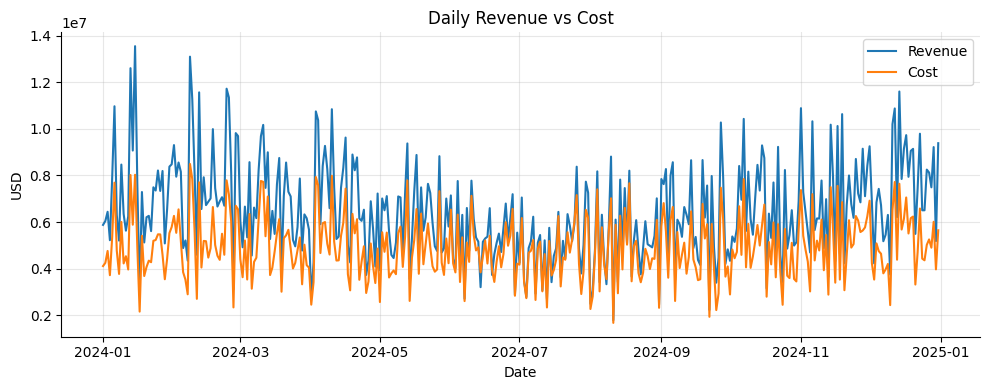

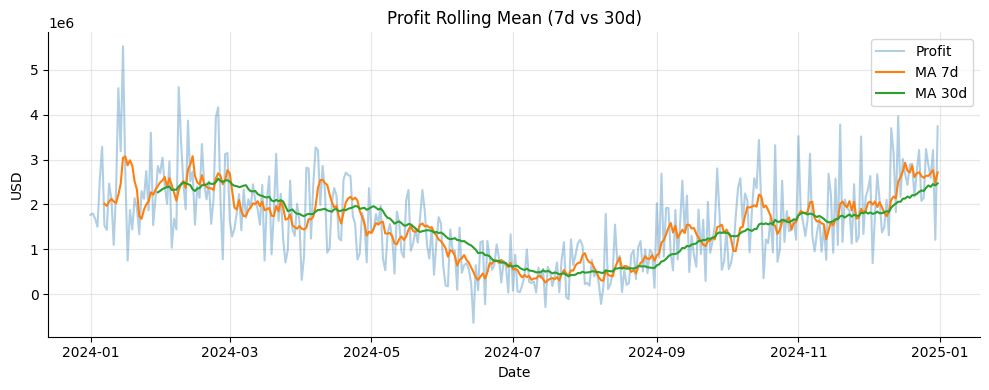

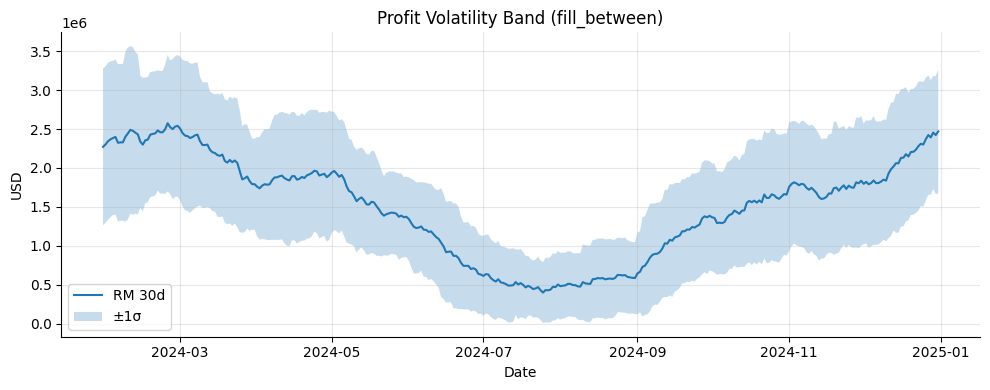

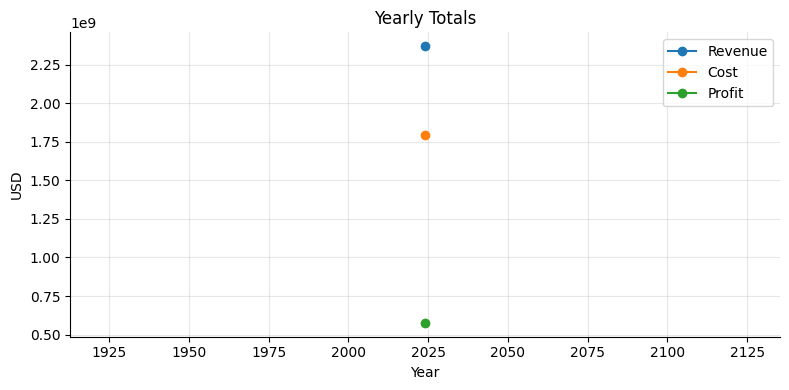

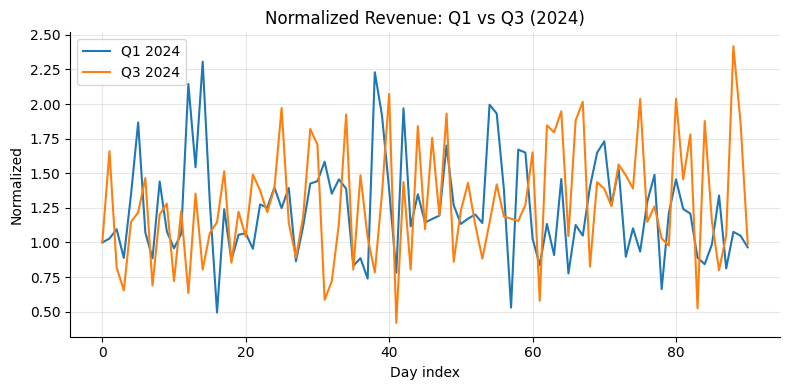

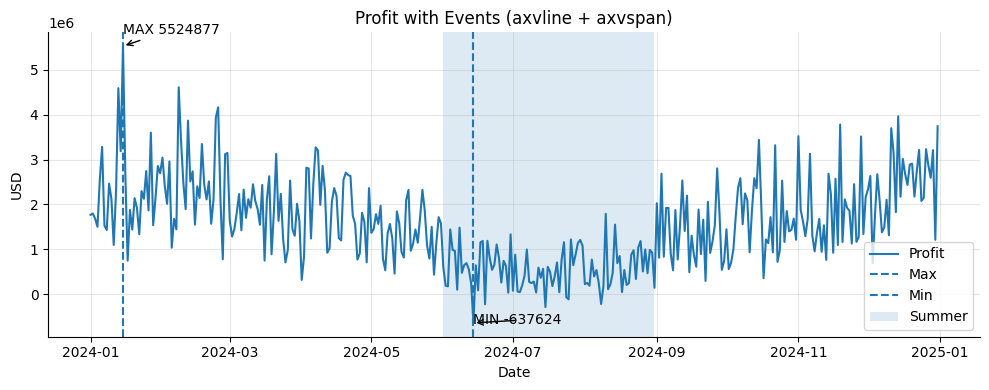

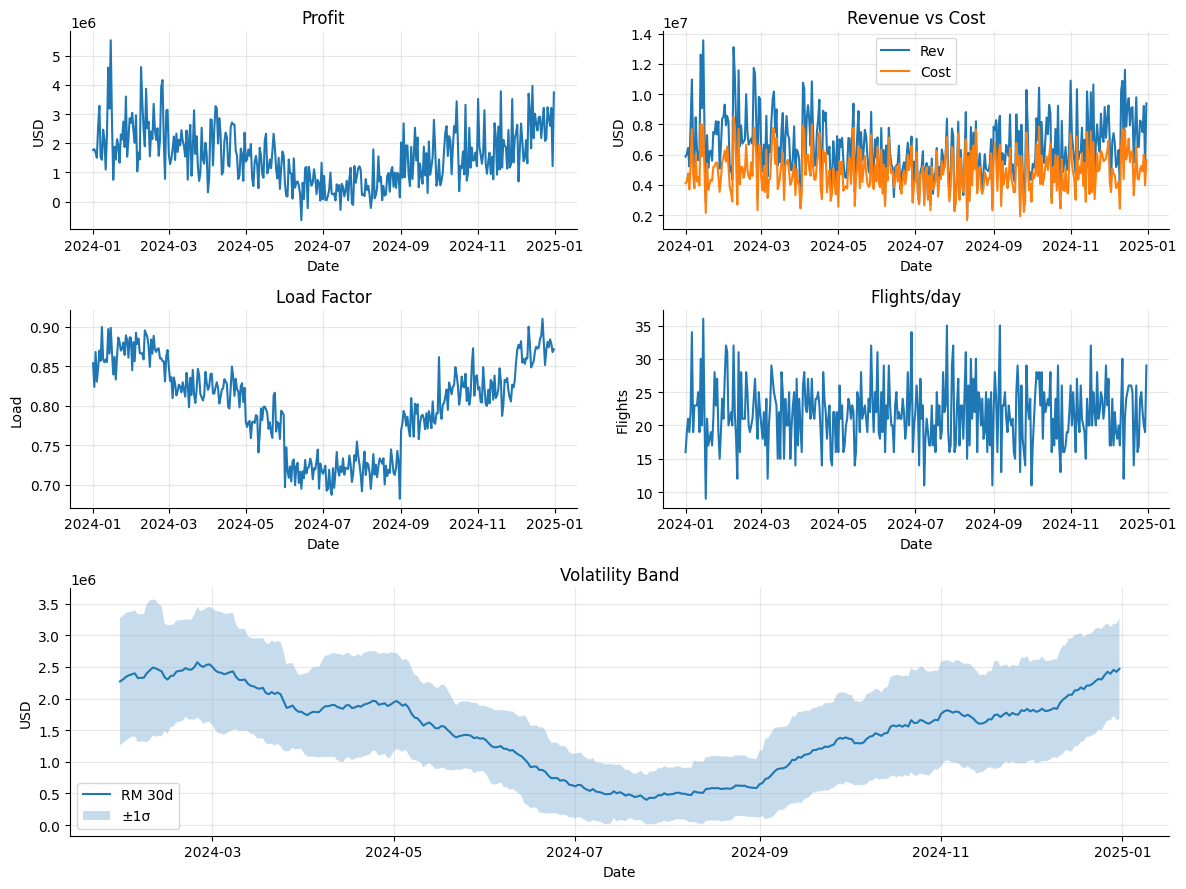

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

CSV_PATH = r"C:\Users\yelypk\Desktop\Data-visualization\airline_route_profitability.csv"

df = pd.read_csv(CSV_PATH, sep = ",", parse_dates=["Flight_Date"]).sort_values("Flight_Date")

D = (df.groupby("Flight_Date").agg(
        Rev=("Total_Revenue","sum"),
        Cost=("Total_Cost","sum"),
        Profit=("Profit","sum"),
        Load=("Load_Factor","mean"),
        Flights=("Flight_Number","count"))
     .sort_index())

idx = pd.date_range(D.index.min(), D.index.max(), freq="D")
D = D.reindex(idx); D.index.name = "Date"
D[["Rev","Cost","Profit","Flights"]] = D[["Rev","Cost","Profit","Flights"]].fillna(0)
D["Load"] = D["Load"].interpolate(limit_direction="both")

D.info(); D.describe()

def style(ax, title, y="", x="Date"):
    ax.set(title=title, xlabel=x, ylabel=y); ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

def norm(s):
    b = s.iloc[0] if len(s) else 1.0
    return s / (b if b != 0 else 1e-9)

def figax(w=10,h=4):
    return plt.subplots(figsize=(w,h))

fig, ax = figax()
ax.plot(D.index, D["Rev"], label="Revenue")
ax.plot(D.index, D["Cost"], label="Cost")
style(ax, "Daily Revenue vs Cost", "USD"); ax.legend()
fig.tight_layout(); plt.show()

w1, w2, win = 7, 30, 30
ma1, ma2 = D["Profit"].rolling(w1).mean(), D["Profit"].rolling(w2).mean()
rm, rs  = D["Profit"].rolling(win).mean(), D["Profit"].rolling(win).std()

fig, ax = figax()
ax.plot(D.index, D["Profit"], alpha=0.35, label="Profit")
ax.plot(D.index, ma1, label=f"MA {w1}d")
ax.plot(D.index, ma2, label=f"MA {w2}d")
style(ax, "Profit Rolling Mean (7d vs 30d)", "USD"); ax.legend()
fig.tight_layout(); plt.show()

fig, ax = figax()
ax.plot(D.index, rm, label=f"RM {win}d")
ax.fill_between(D.index, rm-rs, rm+rs, alpha=0.25, label="±1σ")
style(ax, "Profit Volatility Band (fill_between)", "USD"); ax.legend()
fig.tight_layout(); plt.show()

Y = D.resample("YE")[["Rev","Cost","Profit"]].sum(); Y.index = Y.index.year
fig, ax = figax(8,4)
ax.plot(Y.index, Y["Rev"], marker="o", label="Revenue")
ax.plot(Y.index, Y["Cost"], marker="o", label="Cost")
ax.plot(Y.index, Y["Profit"], marker="o", label="Profit")
style(ax, "Yearly Totals", "USD", "Year"); ax.legend()
fig.tight_layout(); plt.show()

yrs = sorted(D.index.year.unique())

if len(yrs) >= 2:
    a, b = D.loc[str(yrs[-2]), "Rev"], D.loc[str(yrs[-1]), "Rev"]
    la, lb, ttl = str(yrs[-2]), str(yrs[-1]), f"Normalized Revenue: {yrs[-2]} vs {yrs[-1]}"
else:
    y = yrs[0]; Q = D.loc[str(y)]
    a, b = Q[Q.index.quarter==1]["Rev"], Q[Q.index.quarter==3]["Rev"]
    la, lb, ttl = f"Q1 {y}", f"Q3 {y}", f"Normalized Revenue: Q1 vs Q3 ({y})"

n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
fig, ax = figax(8,4)
ax.plot(range(n), norm(a).values, label=la)
ax.plot(range(n), norm(b).values, label=lb)
style(ax, ttl, "Normalized", "Day index"); ax.legend()
fig.tight_layout(); plt.show()

tmax, tmin = D["Profit"].idxmax(), D["Profit"].idxmin()
fig, ax = figax()
ax.plot(D.index, D["Profit"], label="Profit")
ax.axvline(tmax, linestyle="--", label="Max"); ax.axvline(tmin, linestyle="--", label="Min")
ax.annotate(f"MAX {D.loc[tmax,'Profit']:.0f}", (tmax, D.loc[tmax,"Profit"]),
            xytext=(tmax, D.loc[tmax,"Profit"]*1.05 if D.loc[tmax,"Profit"] else 1),
            arrowprops=dict(arrowstyle="->"))
ax.annotate(f"MIN {D.loc[tmin,'Profit']:.0f}", (tmin, D.loc[tmin,"Profit"]),
            xytext=(tmin, D.loc[tmin,"Profit"]*1.05 if D.loc[tmin,"Profit"] else -1),
            arrowprops=dict(arrowstyle="->"))
y0 = D.index.min().year
ax.axvspan(pd.Timestamp(f"{y0}-06-01"), pd.Timestamp(f"{y0}-08-31"), alpha=0.15, label="Summer")
style(ax, "Profit with Events (axvline + axvspan)", "USD"); ax.legend()
fig.tight_layout(); plt.show()

fig = plt.figure(figsize=(12,9))
gs = GridSpec(3,2, figure=fig, height_ratios=[1,1,1.25])
axs = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]),
       fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]),
       fig.add_subplot(gs[2,:])]

axs[0].plot(D.index, D["Profit"]); style(axs[0], "Profit", "USD")
axs[1].plot(D.index, D["Rev"], label="Rev")
axs[1].plot(D.index, D["Cost"], label="Cost"); style(axs[1], "Revenue vs Cost", "USD"); axs[1].legend()
axs[2].plot(D.index, D["Load"]); style(axs[2], "Load Factor", "Load")
axs[3].plot(D.index, D["Flights"]); style(axs[3], "Flights/day", "Flights")
axs[4].plot(D.index, rm, label=f"RM {win}d")
axs[4].fill_between(D.index, rm-rs, rm+rs, alpha=0.25, label="±1σ")
style(axs[4], "Volatility Band", "USD"); axs[4].legend()

fig.tight_layout(); plt.show()